# Student Performance Prediction - Midterm Project

## Problem statement
- **Question:** can we predict whether a secondary-school student passes the final math exam, and identify students at risk of failing?
- **Task type:** binary classification. **Target:** `pass` = 1 if the final grade G3 >= 10 (scale 0-20), otherwise 0.
- **Success metric:** F1 and recall for the "fail" class (finding at-risk students matters more than overall accuracy), plus ROC-AUC. Baseline: always predict "pass" (accuracy 0.671).
- **Two scenarios:** A uses the previous grades G1 and G2; B excludes them (more realistic for early warning).

## Dataset
- **Source:** UCI Machine Learning Repository, "Student Performance" (Cortez & Silva, 2008), file `student-mat.csv` (mathematics course).
- **Size:** 395 students, 33 columns (16 numeric, 17 categorical). **License:** CC BY 4.0.
- **Features:** demographics, family background, study habits, absences, previous grades G1/G2. **Known issues:** small size, class imbalance (67% / 33%), 38 students with G3 = 0 (likely dropouts), noisy `absences`.

In [10]:
import pandas as pd
import urllib.request, zipfile, io

# Source: UCI Machine Learning Repository, Student Performance (CC BY 4.0)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
data = urllib.request.urlopen(url).read()
zipfile.ZipFile(io.BytesIO(data)).extractall()

df = pd.read_csv("student-mat.csv", sep=";")
print(df.shape)
df.head()

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [22]:
df.info()
print(df.isna().sum().sum(), "missing values")
print(df.duplicated().sum(), "duplicates")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 38 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   school           395 non-null    object 
 1   sex              395 non-null    object 
 2   age              395 non-null    int64  
 3   address          395 non-null    object 
 4   famsize          395 non-null    object 
 5   Pstatus          395 non-null    object 
 6   Medu             395 non-null    int64  
 7   Fedu             395 non-null    int64  
 8   Mjob             395 non-null    object 
 9   Fjob             395 non-null    object 
 10  reason           395 non-null    object 
 11  guardian         395 non-null    object 
 12  traveltime       395 non-null    int64  
 13  studytime        395 non-null    int64  
 14  failures         395 non-null    int64  
 15  schoolsup        395 non-null    object 
 16  famsup           395 non-null    object 
 17  paid            

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,health,absences,G1,G2,G3,pass,absences_capped,no_absences,parents_edu,alc_total
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,...,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886,5.525266,0.291139,5.270886,3.772152
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,...,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487,6.868185,0.454864,1.966738,1.984389
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,...,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000,0.000000,0.000000,4.000000,2.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,...,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000,4.000000,0.000000,5.000000,3.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,...,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000,8.000000,1.000000,7.000000,5.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000,38.120000,1.000000,8.000000,10.000000


Class balance (1 = pass, 0 = fail):
pass
1    265
0    130
Name: count, dtype: int64
pass
1    0.671
0    0.329
Name: proportion, dtype: float64

Students with G3 == 0: 38

Absences summary:
count    395.000000
mean       5.708861
std        8.003096
min        0.000000
25%        0.000000
50%        4.000000
75%        8.000000
max       75.000000
Name: absences, dtype: float64
Students with absences > 20: 15

Min / max of key numeric columns:
     age  absences  G1  G2  G3
min   15         0   3   0   0
max   22        75  19  19  20

school: ['GP' 'MS']

sex: ['F' 'M']

address: ['U' 'R']

famsize: ['GT3' 'LE3']

Pstatus: ['A' 'T']

Mjob: ['at_home' 'health' 'other' 'services' 'teacher']

Fjob: ['teacher' 'other' 'services' 'health' 'at_home']

reason: ['course' 'other' 'home' 'reputation']

guardian: ['mother' 'father' 'other']

schoolsup: ['yes' 'no']

famsup: ['no' 'yes']

paid: ['no' 'yes']

activities: ['no' 'yes']

nursery: ['yes' 'no']

higher: ['yes' 'no']

internet: ['no' '

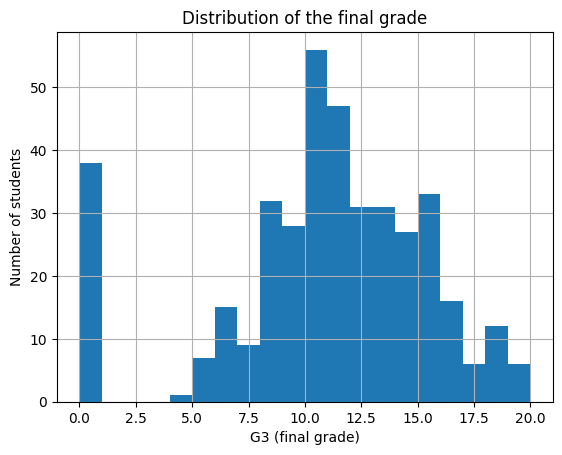

In [12]:
import matplotlib.pyplot as plt

# 1. Target definition: pass if the final grade G3 >= 10 (scale 0-20)
df["pass"] = (df["G3"] >= 10).astype(int)

# 2. Class balance
print("Class balance (1 = pass, 0 = fail):")
print(df["pass"].value_counts())
print(df["pass"].value_counts(normalize=True).round(3))

# 3. Students with a final grade of 0 (possible dropouts)
print("\nStudents with G3 == 0:", (df["G3"] == 0).sum())

# 4. Absences: distribution and outliers
print("\nAbsences summary:")
print(df["absences"].describe())
print("Students with absences > 20:", (df["absences"] > 20).sum())

# 5. Range check for numeric columns
print("\nMin / max of key numeric columns:")
print(df[["age", "absences", "G1", "G2", "G3"]].agg(["min", "max"]))

# 6. Categories in text columns
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")

# 7. Quick look at the target distribution
df["G3"].hist(bins=20)
plt.xlabel("G3 (final grade)")
plt.ylabel("Number of students")
plt.title("Distribution of the final grade")
plt.show()

In [13]:
# --- Data cleaning checks ---

# 1. Who are the students with G3 == 0?
zero_g3 = df[df["G3"] == 0]
print("Students with G3 == 0:", len(zero_g3))
print("  of them with G2 == 0:", (zero_g3["G2"] == 0).sum())
print("  of them with absences == 0:", (zero_g3["absences"] == 0).sum())
print(zero_g3[["G1", "G2", "G3", "absences", "failures"]].describe().round(2))

# 2. Outliers in absences (IQR rule)
q1, q3 = df["absences"].quantile([0.25, 0.75])
upper_bound = q3 + 1.5 * (q3 - q1)
print("\nAbsences upper bound (IQR rule):", upper_bound)
print("Students above the bound:", (df["absences"] > upper_bound).sum())

# 3. Cap absences at the 99th percentile (a cleaned copy, original is kept)
cap = df["absences"].quantile(0.99)
df["absences_capped"] = df["absences"].clip(upper=cap)
print("99th percentile cap:", cap)
print("Max absences before / after:", df["absences"].max(), "/", df["absences_capped"].max())

# 4. Final sanity checks
print("\nMissing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

Students with G3 == 0: 38
  of them with G2 == 0: 13
  of them with absences == 0: 38
          G1     G2    G3  absences  failures
count  38.00  38.00  38.0      38.0     38.00
mean    7.53   4.66   0.0       0.0      0.92
std     1.81   3.70   0.0       0.0      1.08
min     4.00   0.00   0.0       0.0      0.00
25%     6.00   0.00   0.0       0.0      0.00
50%     7.00   5.00   0.0       0.0      1.00
75%     9.00   8.00   0.0       0.0      1.75
max    12.00  10.00   0.0       0.0      3.00

Absences upper bound (IQR rule): 20.0
Students above the bound: 15
99th percentile cap: 38.120000000000005
Max absences before / after: 75 / 38.120000000000005

Missing values: 0
Duplicates: 0


## Data cleaning summary

- **Missing values:** none found (0 of 395 rows affected).
- **Duplicates:** none found.
- **Data types:** 16 numeric and 17 categorical columns; categories checked, no typos or unexpected values.
- **Ranges:** age 15-22, grades 0-20, parental education 0-4 - all valid.
- **Students with G3 = 0 (38 rows):** kept. All of them have absences = 0, which suggests they dropped out and attendance was not recorded. This is a known data issue: absences = 0 mixes full attendance and dropout.
- **Outliers in `absences`:** 15 students above the IQR bound (20). Values were capped at the 99th percentile (38.12) in a new column `absences_capped`; the original column is preserved.
- **Note:** the 99th-percentile cap for `absences` was computed on the full dataset before the split (affects ~4 values). In the final stage it will be fitted on the training set only, inside the pipeline.

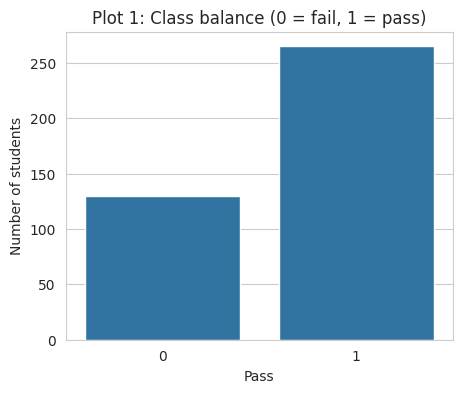

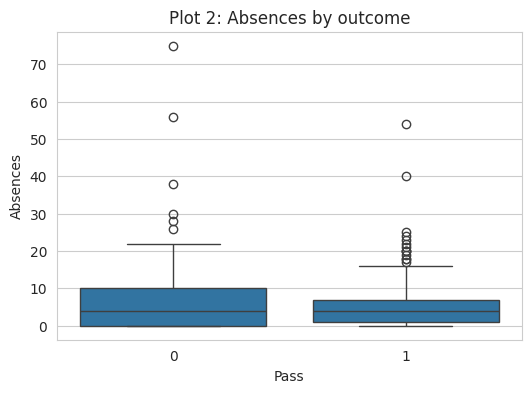

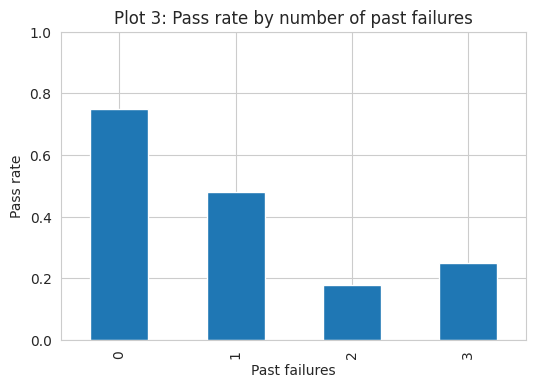

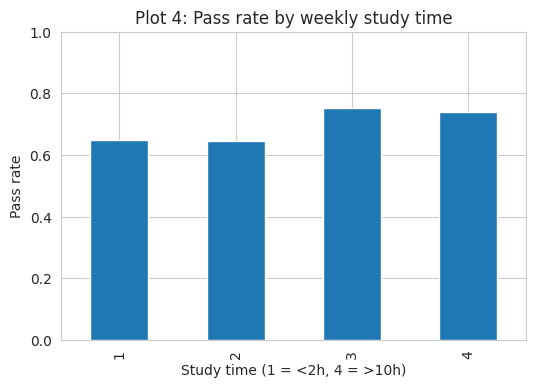

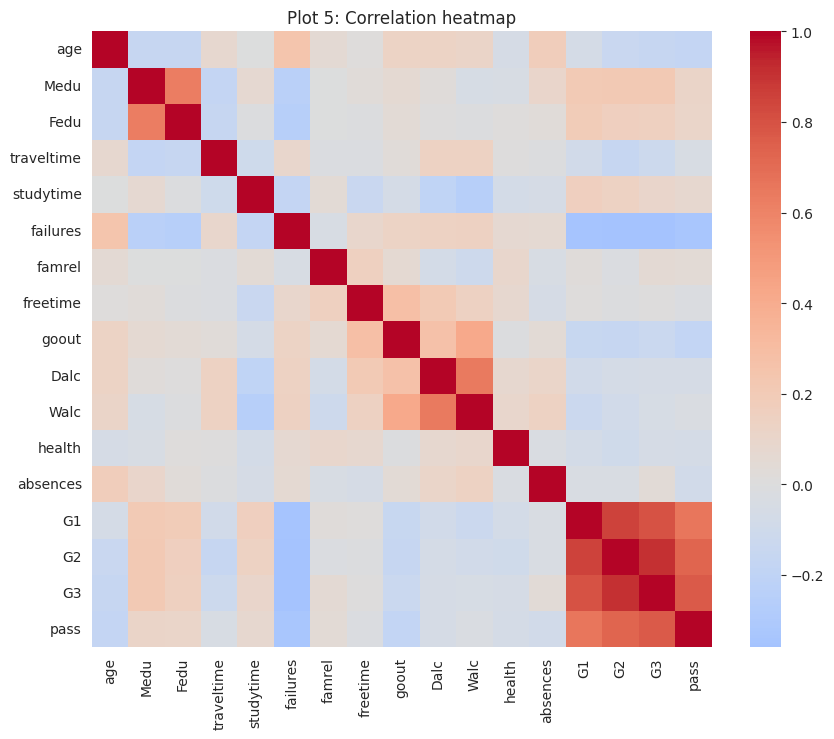

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

# Plot 1: target balance
plt.figure(figsize=(5, 4))
sns.countplot(x="pass", data=df)
plt.title("Plot 1: Class balance (0 = fail, 1 = pass)")
plt.xlabel("Pass")
plt.ylabel("Number of students")
plt.show()

# Plot 2: absences vs outcome
plt.figure(figsize=(6, 4))
sns.boxplot(x="pass", y="absences", data=df)
plt.title("Plot 2: Absences by outcome")
plt.xlabel("Pass")
plt.ylabel("Absences")
plt.show()

# Plot 3: pass rate by past failures
plt.figure(figsize=(6, 4))
df.groupby("failures")["pass"].mean().plot(kind="bar")
plt.title("Plot 3: Pass rate by number of past failures")
plt.xlabel("Past failures")
plt.ylabel("Pass rate")
plt.ylim(0, 1)
plt.show()

# Plot 4: pass rate by weekly study time
plt.figure(figsize=(6, 4))
df.groupby("studytime")["pass"].mean().plot(kind="bar")
plt.title("Plot 4: Pass rate by weekly study time")
plt.xlabel("Study time (1 = <2h, 4 = >10h)")
plt.ylabel("Pass rate")
plt.ylim(0, 1)
plt.show()

# Plot 5: correlation heatmap of numeric features
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include="number").drop(columns=["absences_capped"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Plot 5: Correlation heatmap")
plt.show()

## Finding: zero absences are not reliable

- 115 students have `absences == 0`; their pass rate (56.5%) is lower than for students with at least one absence (71.4%).
- 33% of the zero-absence students have G3 = 0, and all 38 students with G3 = 0 have zero absences. This indicates that attendance was most likely not recorded for students who dropped out.
- Consequence: `absences == 0` mixes full attendance and dropout, so `absences` is a noisy feature. This is listed as a known data issue and will be analysed again in the final stage (e.g. models with and without the G3 = 0 students).

## EDA interpretation

**Plot 1 - Class balance.** About 265 students passed (67%) and about 130 failed (33%). The classes are moderately imbalanced, so accuracy alone is misleading (a model that always predicts "pass" already gets ~67%). We will use stratified splits and report F1 and recall for the "fail" class.

**Plot 2 - Absences by outcome.** The median number of absences is similar in both groups (about 4). The "fail" group has a wider spread and more extreme outliers (up to 75), while its lower quartile is 0. Absences alone separate the classes only weakly. Many students with 0 absences have G3 = 0, which suggests that missing attendance records for dropouts distort this feature.

**Plot 3 - Pass rate by past failures.** The pass rate falls sharply with the number of past failures: about 75% for 0 failures, about 48% for 1 and below 25% for 2-3. Past failures are one of the strongest non-grade predictors. The groups with 2-3 failures are small, so their rates are noisy (the rise at 3 is not reliable).

**Plot 4 - Pass rate by study time.** The pass rate grows only slightly with study time (about 65% for levels 1-2 and about 75% for levels 3-4). The effect is weak, so study time alone is not a strong predictor.

**Plot 5 - Correlation heatmap.** G1, G2 and G3 are strongly correlated with each other and with `pass`, so previous grades dominate the prediction. `failures` is negatively correlated with grades and with `pass`. Parental education (`Medu`, `Fedu`) and alcohol use (`Dalc`, `Walc`) are correlated within their own pairs, which is expected. Most other features, including `absences`, have correlations close to 0 with the target. `pass` is derived from G3, so G3 must be excluded from the features to avoid target leakage.

In [17]:
# Group sizes behind Plot 3 and Plot 4
print("Students per number of past failures:")
print(df["failures"].value_counts().sort_index())

print("\nStudents per study time level:")
print(df["studytime"].value_counts().sort_index())

# Check of the dropout hypothesis: zero absences vs outcome
df["no_absences"] = (df["absences"] == 0).astype(int)
print("\nPass rate by attendance group (no_absences: 1 = zero absences):")
print(df.groupby("no_absences")["pass"].agg(["mean", "count"]).round(3))

zero_abs = df[df["absences"] == 0]
print("\nShare of G3 == 0 among students with zero absences:",
      round((zero_abs["G3"] == 0).mean(), 3))

Students per number of past failures:
failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

Students per study time level:
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

Pass rate by attendance group (no_absences: 1 = zero absences):
              mean  count
no_absences              
0            0.714    280
1            0.565    115

Share of G3 == 0 among students with zero absences: 0.33


**Plot 3 - Pass rate by past failures.** The pass rate falls sharply with the number of past failures: about 75% for 0 failures (312 students), about 48% for 1 (50 students) and below 25% for 2-3 failures. The groups with 2 and 3 failures are very small (17 and 16 students), so their rates are noisy and the small rise at 3 failures is not reliable. The robust conclusion is that students with no past failures pass much more often.

**Plot 4 - Pass rate by study time.** The pass rate grows only slightly with study time: about 65% for levels 1-2 (105 and 198 students) and about 75% for levels 3-4 (65 and 27 students). Level 4 has only 27 students, so the effect is weak and uncertain. Study time alone is not a strong predictor.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# --- Feature engineering ---
df["parents_edu"] = df["Medu"] + df["Fedu"]   # combined parental education
df["alc_total"] = df["Dalc"] + df["Walc"]     # combined alcohol consumption

# --- Target and feature sets ---
y = df["pass"]

# G3 and pass are removed (target leakage); raw absences is replaced by the capped version
always_drop = ["G3", "pass", "absences", "no_absences"]

features_with_grades = df.drop(columns=always_drop)                    # Scenario A: G1, G2 included
features_without_grades = df.drop(columns=always_drop + ["G1", "G2"])  # Scenario B: no previous grades

# --- Split once by row index: 60% train / 20% validation / 20% test ---
idx_train_val, idx_test = train_test_split(
    df.index, test_size=0.20, stratify=y, random_state=42
)
idx_train, idx_val = train_test_split(
    idx_train_val, test_size=0.25, stratify=y.loc[idx_train_val], random_state=42
)

for name, idx in [("train", idx_train), ("validation", idx_val), ("test", idx_test)]:
    print(f"{name:10s} size = {len(idx):3d}, pass share = {y.loc[idx].mean():.3f}")

# --- Preprocessor builder (fitted later inside a Pipeline, on train only) ---
def make_preprocessor(X):
    numeric_cols = X.select_dtypes(include="number").columns.tolist()
    categorical_cols = X.select_dtypes(include="object").columns.tolist()
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), categorical_cols),
    ])

print("\nScenario A features:", features_with_grades.shape[1])
print("Scenario B features:", features_without_grades.shape[1])

train      size = 237, pass share = 0.671
validation size =  79, pass share = 0.671
test       size =  79, pass share = 0.671

Scenario A features: 34
Scenario B features: 32


In [19]:
# Zero-absence students excluding those with G3 == 0 (likely dropouts)
zero_abs_active = df[(df["absences"] == 0) & (df["G3"] > 0)]
print("Zero-absence students with G3 > 0:", len(zero_abs_active))
print("Pass rate among them:", round(zero_abs_active["pass"].mean(), 3))

Zero-absence students with G3 > 0: 77
Pass rate among them: 0.844


- After excluding the 38 students with G3 = 0, the 77 remaining zero-absence students have a pass rate of 84.4% (vs. 71.4% for students with at least one absence). This supports the explanation: zero absences are normally a sign of good attendance, and the low pass rate of the whole group comes from dropouts whose attendance was not recorded.

In [20]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, make_scorer)

# --- Models (hyperparameters are defaults / simple choices; tuning comes later) ---
def get_models():
    return {
        "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
        "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    }

# Score used for ROC-AUC (probability or decision function, depending on the model)
def get_scores(pipe, X):
    if hasattr(pipe, "predict_proba"):
        return pipe.predict_proba(X)[:, 1]
    return pipe.decision_function(X)

# F1 for the "fail" class (label 0) is used in cross-validation
f1_fail_scorer = make_scorer(f1_score, pos_label=0, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_scenario(scenario_name, X):
    X_train, X_val = X.loc[idx_train], X.loc[idx_val]
    y_train, y_val = y.loc[idx_train], y.loc[idx_val]
    rows = []

    for model_name, model in get_models().items():
        pipe = Pipeline([
            ("prep", make_preprocessor(X)),
            ("model", model),
        ])

        # Cross-validation on the training set only
        cv_f1_fail = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=f1_fail_scorer)

        # Fit on train, evaluate on validation
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_val)

        rows.append({
            "Scenario": scenario_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_val, pred),
            "Precision (fail)": precision_score(y_val, pred, pos_label=0, zero_division=0),
            "Recall (fail)": recall_score(y_val, pred, pos_label=0, zero_division=0),
            "F1 (fail)": f1_score(y_val, pred, pos_label=0, zero_division=0),
            "ROC-AUC": roc_auc_score(y_val, get_scores(pipe, X_val)),
            "CV F1 (fail) mean": cv_f1_fail.mean(),
            "CV F1 (fail) std": cv_f1_fail.std(),
        })
    return pd.DataFrame(rows)

results = pd.concat([
    evaluate_scenario("A: with G1, G2", features_with_grades),
    evaluate_scenario("B: without G1, G2", features_without_grades),
], ignore_index=True)

pd.set_option("display.width", 200)
print(results.round(3).to_string(index=False))

         Scenario                    Model  Accuracy  Precision (fail)  Recall (fail)  F1 (fail)  ROC-AUC  CV F1 (fail) mean  CV F1 (fail) std
   A: with G1, G2 Baseline (most frequent)     0.671             0.000          0.000      0.000    0.500              0.000             0.000
   A: with G1, G2            Decision Tree     0.873             0.900          0.692      0.783    0.833              0.832             0.091
   A: with G1, G2                KNN (k=5)     0.797             0.857          0.462      0.600    0.841              0.587             0.166
   A: with G1, G2                SVM (RBF)     0.899             0.950          0.731      0.826    0.964              0.776             0.082
B: without G1, G2 Baseline (most frequent)     0.671             0.000          0.000      0.000    0.500              0.000             0.000
B: without G1, G2            Decision Tree     0.671             0.500          0.346      0.409    0.671              0.435             0.081

## Results and interpretation (validation set)

- **Baseline** (always "pass") reaches accuracy 0.671 but F1 (fail) = 0, so accuracy alone is misleading here.
- **Scenario A (with G1, G2):** SVM (F1 fail 0.826, ROC-AUC 0.964) and Decision Tree (CV F1 fail 0.832) perform similarly and clearly beat the baseline; KNN is weaker (recall for "fail" 0.462). Differences between SVM and Decision Tree are within the cross-validation standard deviation (~0.09), so no single winner can be declared.
- **Scenario B (without G1, G2):** all models are weak (F1 fail 0.35-0.41, ROC-AUC 0.56-0.67). The Decision Tree has the same accuracy as the baseline (0.671). The SVM precision of 1.0 is based on only 6 predicted "fail" cases (recall 0.231) and should not be over-interpreted.
- **Main finding:** previous grades G1 and G2 explain most of the predictive power. Scenario A is not usable as an early-warning tool, while the realistic Scenario B currently performs poorly.
- **Limitation:** the validation set contains only 26 "fail" students, so each student changes recall by ~3.8 percentage points. All comparisons are preliminary. The test set has not been used yet.

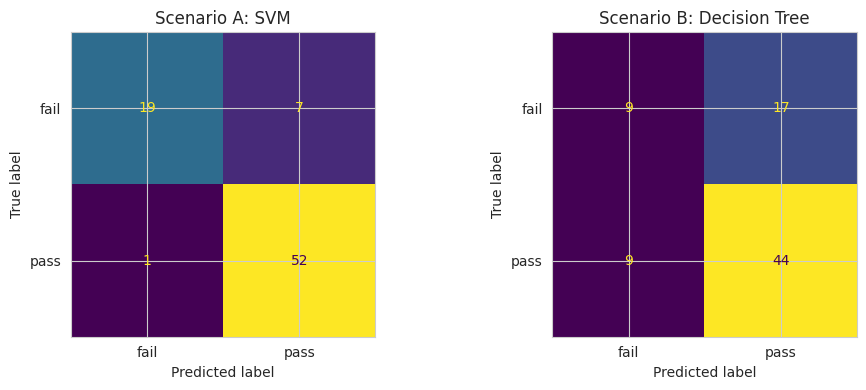

Scenario A, missed 'fail' students: 7
     G1  G2  G3  failures  absences  studytime
328  10   9   9         0         7          3
263  10   9   9         0         4          3
205  10   9   9         1        28          3
347  10  10   9         0         0          3
261   8   8   8         0         2          2
192   7   8   8         0        12          2
183   9   9   8         0        56          2

Scenario A, false alarms: 1
    G1  G2  G3  failures  absences  studytime
95   7  10  10         1         2          4

Scenario B, top 8 features by Decision Tree importance:
num__failures           0.274
num__absences_capped    0.163
num__freetime           0.111
num__goout              0.060
num__Walc               0.056
cat__schoolsup_yes      0.047
cat__Mjob_health        0.043
num__age                0.042
dtype: float64


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def fit_pipeline(model, X):
    pipe = Pipeline([("prep", make_preprocessor(X)), ("model", model)])
    pipe.fit(X.loc[idx_train], y.loc[idx_train])
    return pipe

# --- Best models chosen on validation F1 (fail) ---
pipe_A = fit_pipeline(SVC(kernel="rbf", random_state=42), features_with_grades)
pipe_B = fit_pipeline(DecisionTreeClassifier(max_depth=5, random_state=42), features_without_grades)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pipe, X, title in [
    (axes[0], pipe_A, features_with_grades, "Scenario A: SVM"),
    (axes[1], pipe_B, features_without_grades, "Scenario B: Decision Tree"),
]:
    pred = pipe.predict(X.loc[idx_val])
    ConfusionMatrixDisplay(
        confusion_matrix(y.loc[idx_val], pred, labels=[0, 1]),
        display_labels=["fail", "pass"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

# --- Which "fail" students does the Scenario A model miss? (false negatives) ---
val = df.loc[idx_val].copy()
val["pred_A"] = pipe_A.predict(features_with_grades.loc[idx_val])
missed = val[(val["pass"] == 0) & (val["pred_A"] == 1)]
print("Scenario A, missed 'fail' students:", len(missed))
print(missed[["G1", "G2", "G3", "failures", "absences", "studytime"]])

# --- Same check for the false positives (predicted fail, actually passed) ---
false_alarm = val[(val["pass"] == 1) & (val["pred_A"] == 0)]
print("\nScenario A, false alarms:", len(false_alarm))
print(false_alarm[["G1", "G2", "G3", "failures", "absences", "studytime"]])

# --- Scenario B: most important features of the Decision Tree ---
tree = pipe_B.named_steps["model"]
names = pipe_B.named_steps["prep"].get_feature_names_out()
importances = pd.Series(tree.feature_importances_, index=names).sort_values(ascending=False)
print("\nScenario B, top 8 features by Decision Tree importance:")
print(importances.head(8).round(3))

## Error analysis (validation set)

**Scenario A (SVM).** 19 of 26 "fail" students were found, 7 were missed, and there was 1 false alarm (out of 53 "pass" students). All 7 missed students have G2 between 8 and 10 and a final grade G3 of 8 or 9, i.e. they failed by a very small margin. The single false alarm has G3 = 10, exactly on the threshold. Clear cases, including students with G3 = 0, are classified correctly. The remaining errors are concentrated around the arbitrary pass threshold of 10.

**Scenario B (Decision Tree).** Only 9 of 26 "fail" students were found (17 missed) and there were 9 false alarms, so without previous grades the model is only slightly better than chance for the minority class. The most important features are `failures` (0.274), `absences_capped` (0.163) and `freetime` (0.111). With 237 training rows, the lower-ranked features are likely to reflect noise, and importance does not show the direction of an effect.

**Conclusion.** Previous grades make the problem easy; without them the available behavioural and background features carry little signal. The error pattern in Scenario A is mainly a consequence of the fixed threshold.


## Open problems

1. **Weak Scenario B.** Without G1 and G2 all models are close to the baseline (F1 for "fail" about 0.35-0.41).
2. **Small data.** 395 rows; the validation set has only 26 "fail" students, so results are noisy.
3. **Noisy `absences`.** Zero absences mix full attendance and unrecorded dropouts (all 38 students with G3 = 0 have zero absences).
4. **Arbitrary threshold.** Most Scenario A errors lie at G3 = 8-10.
5. **Redundant features.** Medu/Fedu and Dalc/Walc are kept next to their sums (`parents_edu`, `alc_total`).
6. **Untuned models.** Hyperparameters are defaults or simple choices.
7. **Cap computed before the split.** The 99th-percentile cap for `absences` uses the full dataset (minor leakage, ~4 values); it will be moved inside the pipeline and fitted on the training set only.


## Plan for the final stage

1. Hyperparameter tuning with GridSearchCV (Decision Tree depth, KNN k, SVM C and gamma), selected by cross-validation F1 for "fail".
2. Handle the class imbalance: `class_weight="balanced"` and decision-threshold tuning to favour recall for "fail".
3. Feature selection: remove redundant features, test models with and without the dropout students (G3 = 0).
4. Try the regression formulation (predict G3) and a three-class risk group version to reduce the threshold effect.
5. Repeated stratified cross-validation to get more stable estimates.
6. Use the second dataset (Portuguese course) carefully: some students appear in both files, so merging needs a student-level split to avoid leakage between train and test.
7. Final evaluation once on the untouched test set.